In [47]:
print ("Hello Colab")

Hello Colab


In [48]:
import pandas as pd

In [49]:
import seaborn as sns

In [50]:
df = pd.read_csv("https://raw.githubusercontent.com/evelinpanozzo/logistics-sla-project/refs/heads/main/dynamic_supply_chain_logistics_dataset.csv")

visualizar la base de datos

In [51]:
df.head()

,timestamp,vehicle_gps_latitude,vehicle_gps_longitude,fuel_consumption_rate,eta_variation_hours,traffic_congestion_level,warehouse_inventory_level,loading_unloading_time,handling_equipment_availability,order_fulfillment_status,...,iot_temperature,cargo_condition_status,route_risk_level,customs_clearance_time,driver_behavior_score,fatigue_monitoring_score,disruption_likelihood_score,delay_probability,risk_classification,delivery_time_deviation
0,2021-01-01 00:00:00,40.375568,-77.014318,5.136512,4.998009,5.927586,985.716862,4.951392,0.481294,0.761166,...,0.574400,0.777263,1.182116,0.502006,0.033843,0.978599,0.506152,0.885291,Moderate Risk,9.110682
1,2021-01-01 01:00:00,33.507818,-117.036902,5.101512,0.984929,1.591992,396.700206,1.030379,0.620780,0.196594,...,-9.753493,0.091839,9.611988,0.966774,0.201725,0.918586,0.980784,0.544178,High Risk,8.175281
2,2021-01-01 02:00:00,30.020640,-75.269224,5.090803,4.972665,8.787765,832.408935,4.220229,0.810933,0.152742,...,-6.491034,0.253529,6.570431,0.945627,0.264045,0.394215,0.998633,0.803322,High Risk,1.283594
3,2021-01-01 03:00:00,36.649223,-70.190529,8.219558,3.095064,0.045257,0.573283,0.530186,0.008525,0.811885,...,-0.151276,0.877576,0.548952,4.674035,0.362885,0.905444,0.993320,0.025977,High Risk,9.304897
4,2021-01-01 04:00:00,30.001279,-70.012195,5.000075,3.216077,8.004851,914.925067,3.620890,0.020083,0.053659,...,2.429448,0.262081,8.861443,3.445429,0.016957,0.258702,0.912433,0.991122,High Risk,7.752484


Visualizar los tipos de datos en cada columna




In [52]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32065 entries, 0 to 32064
Data columns (total 26 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   timestamp                        32065 non-null  object 
 1   vehicle_gps_latitude             32065 non-null  float64
 2   vehicle_gps_longitude            32065 non-null  float64
 3   fuel_consumption_rate            32065 non-null  float64
 4   eta_variation_hours              32065 non-null  float64
 5   traffic_congestion_level         32065 non-null  float64
 6   warehouse_inventory_level        32065 non-null  float64
 7   loading_unloading_time           32065 non-null  float64
 8   handling_equipment_availability  32065 non-null  float64
 9   order_fulfillment_status         32065 non-null  float64
 10  weather_condition_severity       32065 non-null  float64
 11  port_congestion_level            32065 non-null  float64
 12  shipping_costs    

***Antes de calcular el SLA, generamos la evaluacion y transformación de los tipos de datos...***

In [53]:
#  Modificación columna timestamp
df['timestamp'] = pd.to_datetime(df['timestamp']) #Es importante porque se va a calcular SLA por día/mes

In [54]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32065 entries, 0 to 32064
Data columns (total 26 columns):
 #   Column                           Non-Null Count  Dtype         
---  ------                           --------------  -----         
 0   timestamp                        32065 non-null  datetime64[ns]
 1   vehicle_gps_latitude             32065 non-null  float64       
 2   vehicle_gps_longitude            32065 non-null  float64       
 3   fuel_consumption_rate            32065 non-null  float64       
 4   eta_variation_hours              32065 non-null  float64       
 5   traffic_congestion_level         32065 non-null  float64       
 6   warehouse_inventory_level        32065 non-null  float64       
 7   loading_unloading_time           32065 non-null  float64       
 8   handling_equipment_availability  32065 non-null  float64       
 9   order_fulfillment_status         32065 non-null  float64       
 10  weather_condition_severity       32065 non-null  float64  

A fin de verificación de datos erróneos cómo: strings vacíos, espacios en blanco y los "null" del tipo texto, se ejecuta la siguiente expresión del tipo Booleano (Valor 0/False)

In [55]:
df.isnull().sum()

,0
timestamp,0
vehicle_gps_latitude,0
vehicle_gps_longitude,0
fuel_consumption_rate,0
eta_variation_hours,0
traffic_congestion_level,0
warehouse_inventory_level,0
loading_unloading_time,0
handling_equipment_availability,0
order_fulfillment_status,0


El dataset posee registros de los años 2021/2022 pero todos los meses del año solo figuran para el 2021 porque le filtramos por este último año: Se crea DataFrame.

In [56]:
df_2021 = df[df['timestamp'].dt.year == 2021]

In [57]:
df_2021['timestamp'].dt.year.unique()

array([2021], dtype=int32)

In [58]:
df.shape

(32065, 26)

Ver las primeras filas de mi DataFrame

In [59]:
df_2021.head()

,timestamp,vehicle_gps_latitude,vehicle_gps_longitude,fuel_consumption_rate,eta_variation_hours,traffic_congestion_level,warehouse_inventory_level,loading_unloading_time,handling_equipment_availability,order_fulfillment_status,...,iot_temperature,cargo_condition_status,route_risk_level,customs_clearance_time,driver_behavior_score,fatigue_monitoring_score,disruption_likelihood_score,delay_probability,risk_classification,delivery_time_deviation
0,2021-01-01 00:00:00,40.375568,-77.014318,5.136512,4.998009,5.927586,985.716862,4.951392,0.481294,0.761166,...,0.574400,0.777263,1.182116,0.502006,0.033843,0.978599,0.506152,0.885291,Moderate Risk,9.110682
1,2021-01-01 01:00:00,33.507818,-117.036902,5.101512,0.984929,1.591992,396.700206,1.030379,0.620780,0.196594,...,-9.753493,0.091839,9.611988,0.966774,0.201725,0.918586,0.980784,0.544178,High Risk,8.175281
2,2021-01-01 02:00:00,30.020640,-75.269224,5.090803,4.972665,8.787765,832.408935,4.220229,0.810933,0.152742,...,-6.491034,0.253529,6.570431,0.945627,0.264045,0.394215,0.998633,0.803322,High Risk,1.283594
3,2021-01-01 03:00:00,36.649223,-70.190529,8.219558,3.095064,0.045257,0.573283,0.530186,0.008525,0.811885,...,-0.151276,0.877576,0.548952,4.674035,0.362885,0.905444,0.993320,0.025977,High Risk,9.304897
4,2021-01-01 04:00:00,30.001279,-70.012195,5.000075,3.216077,8.004851,914.925067,3.620890,0.020083,0.053659,...,2.429448,0.262081,8.861443,3.445429,0.016957,0.258702,0.912433,0.991122,High Risk,7.752484


Ver las últimas filas de mi DataFrame

In [60]:
df_2021.tail()

,timestamp,vehicle_gps_latitude,vehicle_gps_longitude,fuel_consumption_rate,eta_variation_hours,traffic_congestion_level,warehouse_inventory_level,loading_unloading_time,handling_equipment_availability,order_fulfillment_status,...,iot_temperature,cargo_condition_status,route_risk_level,customs_clearance_time,driver_behavior_score,fatigue_monitoring_score,disruption_likelihood_score,delay_probability,risk_classification,delivery_time_deviation
8755,2021-12-31 19:00:00,30.005979,-90.196458,5.293510,-0.834869,9.689533,852.093985,2.502879,0.659683,0.999983,...,-9.959503,0.686253,10.000000,3.214982,0.232630,0.399165,0.985608,0.999979,High Risk,-0.430182
8756,2021-12-31 20:00:00,30.203338,-89.293525,5.000710,-1.071880,3.226226,497.321341,1.083978,0.000003,0.217231,...,-9.748550,0.073343,0.873882,2.183085,0.979909,0.254921,0.827646,0.999968,High Risk,6.190065
8757,2021-12-31 21:00:00,30.197144,-115.493986,9.378763,4.944122,9.807176,13.453240,4.469262,0.001874,0.934957,...,-9.999127,0.000013,2.308961,4.433492,0.128435,0.003857,0.917991,0.991617,High Risk,1.740547
8758,2021-12-31 22:00:00,30.058723,-99.911377,6.575377,1.317836,5.046628,12.801086,1.126800,0.008327,0.407968,...,-9.403336,0.183286,9.724184,0.785331,0.351352,0.080906,0.998610,0.656978,High Risk,3.128893
8759,2021-12-31 23:00:00,47.339203,-118.254991,5.000451,4.899140,5.223284,74.136793,3.020670,0.000756,1.000000,...,-9.994072,0.793542,1.452409,2.155889,0.058355,0.000483,0.893374,0.099085,High Risk,9.999279


Generamos una nueva columna que muestre los meses a partir de nuestra columna timestamp:

In [61]:
df_2021 = df[df['timestamp'].dt.year == 2021].copy()
df_2021["month"] = df_2021["timestamp"].dt.month_name()

In [62]:
df_2021.head()

,timestamp,vehicle_gps_latitude,vehicle_gps_longitude,fuel_consumption_rate,eta_variation_hours,traffic_congestion_level,warehouse_inventory_level,loading_unloading_time,handling_equipment_availability,order_fulfillment_status,...,cargo_condition_status,route_risk_level,customs_clearance_time,driver_behavior_score,fatigue_monitoring_score,disruption_likelihood_score,delay_probability,risk_classification,delivery_time_deviation,month
0,2021-01-01 00:00:00,40.375568,-77.014318,5.136512,4.998009,5.927586,985.716862,4.951392,0.481294,0.761166,...,0.777263,1.182116,0.502006,0.033843,0.978599,0.506152,0.885291,Moderate Risk,9.110682,January
1,2021-01-01 01:00:00,33.507818,-117.036902,5.101512,0.984929,1.591992,396.700206,1.030379,0.620780,0.196594,...,0.091839,9.611988,0.966774,0.201725,0.918586,0.980784,0.544178,High Risk,8.175281,January
2,2021-01-01 02:00:00,30.020640,-75.269224,5.090803,4.972665,8.787765,832.408935,4.220229,0.810933,0.152742,...,0.253529,6.570431,0.945627,0.264045,0.394215,0.998633,0.803322,High Risk,1.283594,January
3,2021-01-01 03:00:00,36.649223,-70.190529,8.219558,3.095064,0.045257,0.573283,0.530186,0.008525,0.811885,...,0.877576,0.548952,4.674035,0.362885,0.905444,0.993320,0.025977,High Risk,9.304897,January
4,2021-01-01 04:00:00,30.001279,-70.012195,5.000075,3.216077,8.004851,914.925067,3.620890,0.020083,0.053659,...,0.262081,8.861443,3.445429,0.016957,0.258702,0.912433,0.991122,High Risk,7.752484,January


# Comenzando con el cálculo de SLA
Primero creamos la categorización:


*   ≤ 0 → Entrega en tiempo (cumple SLA)
*   > 0 → Entrega con demora (no cumple SLA)





In [63]:
df_2021["SLA_status"] = df_2021["delivery_time_deviation"].apply(
    lambda x: "CUMPLE" if x <= 0 else "NO CUMPLE"
)

Crear columna SLA numérica Donde:

*   1 = Cumple
*   0 = No cumple



In [64]:
df_2021["SLA"] = df_2021["delivery_time_deviation"].apply(
    lambda x: 1 if x <= 0 else 0
)

Calculo de SLA de todo el año 2021


In [65]:
sla_total_2021 = df_2021["SLA"].mean() * 100
print(f"SLA 2021: {sla_total_2021:.2f}%")

SLA 2021: 17.76%


DataFrame para graficar: SLA por mes

In [66]:
sla_mensual = df_2021.groupby("month")["SLA"].mean() * 100
sla_mensual = sla_mensual.reset_index()

In [67]:
df_2021.head()

,timestamp,vehicle_gps_latitude,vehicle_gps_longitude,fuel_consumption_rate,eta_variation_hours,traffic_congestion_level,warehouse_inventory_level,loading_unloading_time,handling_equipment_availability,order_fulfillment_status,...,customs_clearance_time,driver_behavior_score,fatigue_monitoring_score,disruption_likelihood_score,delay_probability,risk_classification,delivery_time_deviation,month,SLA_status,SLA
0,2021-01-01 00:00:00,40.375568,-77.014318,5.136512,4.998009,5.927586,985.716862,4.951392,0.481294,0.761166,...,0.502006,0.033843,0.978599,0.506152,0.885291,Moderate Risk,9.110682,January,NO CUMPLE,0
1,2021-01-01 01:00:00,33.507818,-117.036902,5.101512,0.984929,1.591992,396.700206,1.030379,0.620780,0.196594,...,0.966774,0.201725,0.918586,0.980784,0.544178,High Risk,8.175281,January,NO CUMPLE,0
2,2021-01-01 02:00:00,30.020640,-75.269224,5.090803,4.972665,8.787765,832.408935,4.220229,0.810933,0.152742,...,0.945627,0.264045,0.394215,0.998633,0.803322,High Risk,1.283594,January,NO CUMPLE,0
3,2021-01-01 03:00:00,36.649223,-70.190529,8.219558,3.095064,0.045257,0.573283,0.530186,0.008525,0.811885,...,4.674035,0.362885,0.905444,0.993320,0.025977,High Risk,9.304897,January,NO CUMPLE,0
4,2021-01-01 04:00:00,30.001279,-70.012195,5.000075,3.216077,8.004851,914.925067,3.620890,0.020083,0.053659,...,3.445429,0.016957,0.258702,0.912433,0.991122,High Risk,7.752484,January,NO CUMPLE,0


In [68]:
df_2021["delivery_time_deviation"].describe()

,delivery_time_deviation
count,8760.000000
mean,5.240849
std,4.167040
min,-1.999998
25%,1.289632
50%,6.253691
75%,9.318613
max,10.000000


Cálculo duración SLA: Definimos SLA

In [69]:
df_2021["SLA"] = df_2021["delivery_time_deviation"] <= 0
df_2021["SLA"].mean() * 100

np.float64(17.76255707762557)

In [70]:
df_2021["delay_duration"] = pd.to_timedelta(
    df_2021["delivery_time_deviation"],
    unit="h"
)

In [71]:
df_2021.head()

,timestamp,vehicle_gps_latitude,vehicle_gps_longitude,fuel_consumption_rate,eta_variation_hours,traffic_congestion_level,warehouse_inventory_level,loading_unloading_time,handling_equipment_availability,order_fulfillment_status,...,driver_behavior_score,fatigue_monitoring_score,disruption_likelihood_score,delay_probability,risk_classification,delivery_time_deviation,month,SLA_status,SLA,delay_duration
0,2021-01-01 00:00:00,40.375568,-77.014318,5.136512,4.998009,5.927586,985.716862,4.951392,0.481294,0.761166,...,0.033843,0.978599,0.506152,0.885291,Moderate Risk,9.110682,January,NO CUMPLE,False,0 days 09:06:38.454556867
1,2021-01-01 01:00:00,33.507818,-117.036902,5.101512,0.984929,1.591992,396.700206,1.030379,0.620780,0.196594,...,0.201725,0.918586,0.980784,0.544178,High Risk,8.175281,January,NO CUMPLE,False,0 days 08:10:31.011382858
2,2021-01-01 02:00:00,30.020640,-75.269224,5.090803,4.972665,8.787765,832.408935,4.220229,0.810933,0.152742,...,0.264045,0.394215,0.998633,0.803322,High Risk,1.283594,January,NO CUMPLE,False,0 days 01:17:00.937541018
3,2021-01-01 03:00:00,36.649223,-70.190529,8.219558,3.095064,0.045257,0.573283,0.530186,0.008525,0.811885,...,0.362885,0.905444,0.993320,0.025977,High Risk,9.304897,January,NO CUMPLE,False,0 days 09:18:17.629814120
4,2021-01-01 04:00:00,30.001279,-70.012195,5.000075,3.216077,8.004851,914.925067,3.620890,0.020083,0.053659,...,0.016957,0.258702,0.912433,0.991122,High Risk,7.752484,January,NO CUMPLE,False,0 days 07:45:08.941901544


*A fin de comenzar con la visualización, generamos una AGRUPACIÓN por el MES y el ESTADO DE SLA*



In [72]:
tabla_sla = df_2021.groupby(["month", "SLA_status"]).size().unstack()
tabla_sla

SLA_status,CUMPLE,NO CUMPLE
month,,
April,133,587
August,128,616
December,116,628
February,128,544
January,127,617
July,129,615
June,134,586
March,136,608
May,136,608


*Ordenamos cronologicamente los meses...*

In [73]:
orden_meses = [
    "January", "February", "March", "April",
    "May", "June", "July", "August",
    "September", "October", "November", "December"
]

tabla_sla = tabla_sla.reindex(orden_meses)
tabla_sla

SLA_status,CUMPLE,NO CUMPLE
month,,
January,127,617
February,128,544
March,136,608
April,133,587
May,136,608
June,134,586
July,129,615
August,128,616
September,131,589


*Nuestro primer gráfico*...

In [74]:
import matplotlib.pyplot as plt
import numpy as np

%matplotlib inline

**El siguiene gráfico de barras, representa la cantidad total de tareas por los diferentes meses del año 2021, Dividida en las Categorias: CUMPLE / NO CUMPLE**

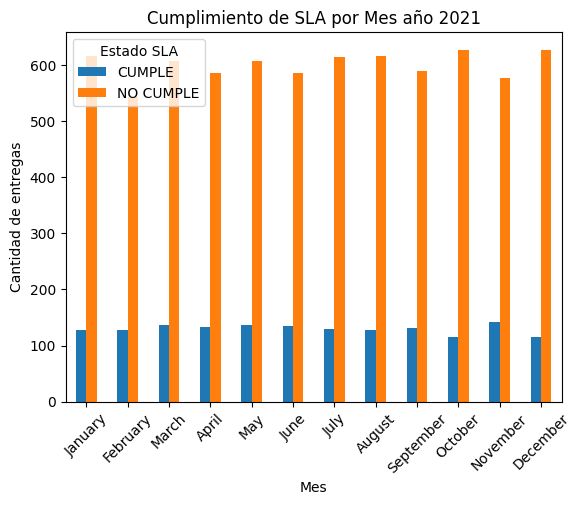

In [75]:
tabla_sla.plot(kind="bar")

plt.title("Cumplimiento de SLA por Mes año 2021")
plt.xlabel("Mes")
plt.ylabel("Cantidad de entregas")
plt.xticks(rotation=45)
plt.legend(title="Estado SLA")

plt.show()

**El siguiente gráfico de columna apiladas representa el 100% de las entregas de un mes, dividida proporcionalmente en las Categorias: CUMPLE / NO CUMPLE.**

In [76]:
tabla_sla = df_2021.groupby(["month", "SLA_status"]).size().unstack()
tabla_pct = tabla_sla.div(tabla_sla.sum(axis=1), axis=0) * 100

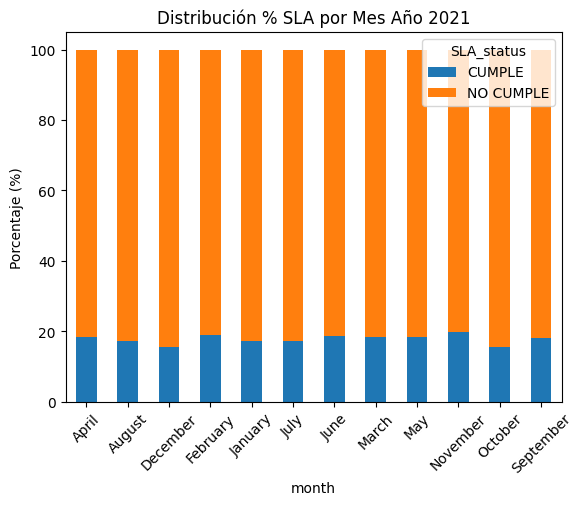

In [77]:
tabla_pct.plot(kind="bar", stacked=True)

plt.title("Distribución % SLA por Mes Año 2021")
plt.ylabel("Porcentaje (%)")
plt.xticks(rotation=45)

plt.show()

*Utilizamos pie chart para mostrar el cumplimiento ANUAL*

---



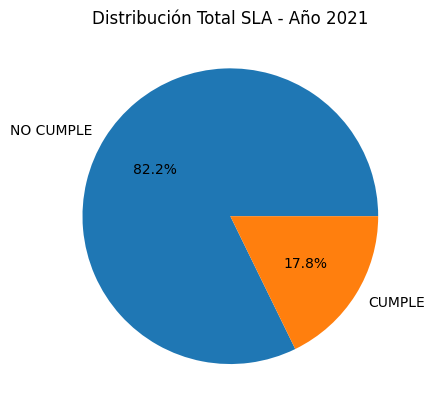

In [78]:
total_anual = df_2021["SLA_status"].value_counts()

plt.pie(total_anual, labels=total_anual.index, autopct="%1.1f%%")
plt.title("Distribución Total SLA - Año 2021")
plt.show()

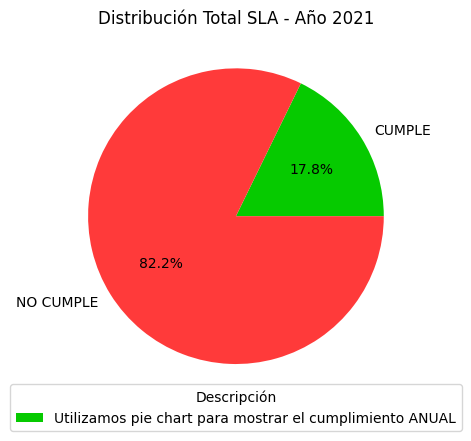

In [79]:

total_anual = total_anual[["CUMPLE", "NO CUMPLE"]]

colores = ["#06CA00", "#FF3A3A"]

plt.pie(
    total_anual,
    labels=total_anual.index,
    autopct="%1.1f%%",
    colors=colores
)

plt.title("Distribución Total SLA - Año 2021")

plt.legend(
    title="Descripción",
    labels=["Utilizamos pie chart para mostrar el cumplimiento ANUAL"],
    loc="lower center",
    bbox_to_anchor=(0.5, -0.1)
)

plt.show()

*Seaborn: diagrama de caja (boxplot), analisis la distribución mensual de la variable delivery_time_deviation. Esta visualización permite observar la mediana, el rango intercuartílico y la presencia de valores atípicos en cada mes, facilitando la comparación del comportamiento estadístico de las demoras a lo largo del año 2021.*

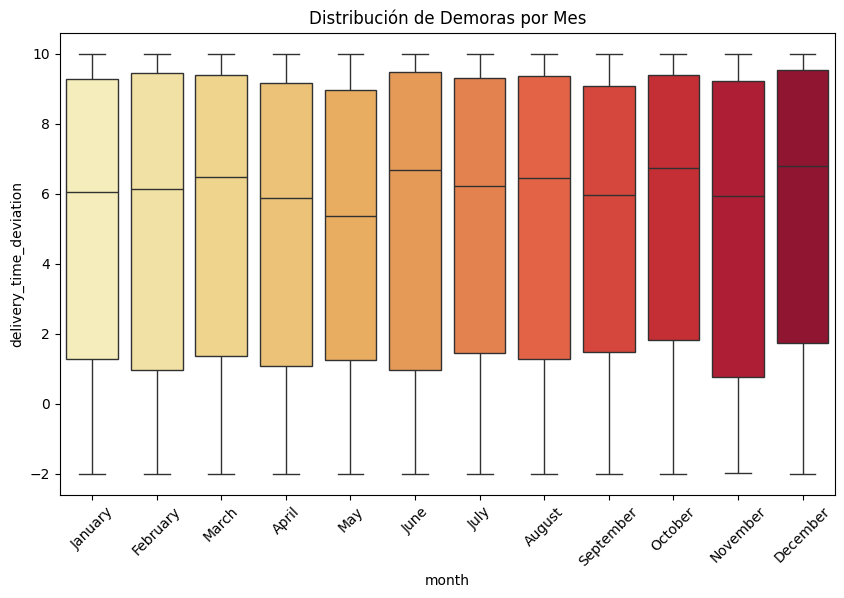

In [80]:
plt.figure(figsize=(10,6))

sns.boxplot(
    data=df_2021,
    x="month",
    y="delivery_time_deviation",
    hue="month",
    palette="YlOrRd",
    legend=False
)

plt.xticks(rotation=45)
plt.title("Distribución de Demoras por Mes")
plt.show()

*Heatmap: Se utilizó un mapa de calor (heatmap) para representar el porcentaje de cumplimiento del SLA por mes. Esta visualización emplea una escala de colores para reflejar la intensidad de los valores, permitiendo identificar de manera inmediata los meses con mejor y peor desempeño.*

*   Filas → Meses

*   Columnas → Estado del SLA (CUMPLE / NO CUMPLE)
*   Valores dentro de cada celda → Porcentaje


*  Color → Intensidad del cumplimiento


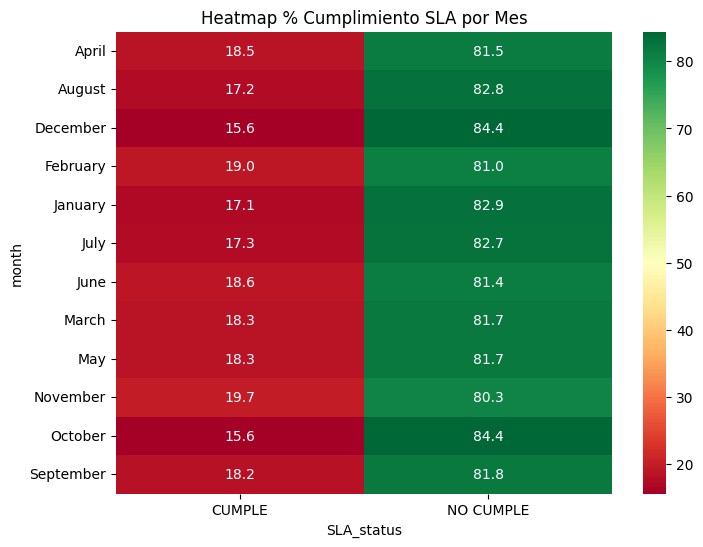

In [81]:
plt.figure(figsize=(8,6))

sns.heatmap(
    tabla_pct,
    annot=True,
    fmt=".1f",
    cmap="RdYlGn"
)

plt.title("Heatmap % Cumplimiento SLA por Mes")
plt.show()

# -- Últimas correcciones en base a la devolución de la primera entrega

- La variable SLA_STATUS está desbaleanceada, esto quiere decir que el modelo "aprende" a decir "NO CUMPLE"
- Explicación formal: Se detecta un desbalance en la variable objetivo (SLA_status), donde la clase “No cumple” presenta una mayor proporción respecto a “Cumple”. Este tipo de distribución puede sesgar los modelos predictivos, favoreciendo la predicción de la clase mayoritaria y afectando la capacidad de generalización.

In [82]:
from sklearn.model_selection import train_test_split

# Variables predictoras (X) y objetivo (y)
X = df_2021.drop("SLA_status", axis=1)
y = df_2021["SLA_status"]

# División con estratificación
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

-- Se confirma el desbalance de clases

In [83]:
y.value_counts(normalize=True)

,proportion
SLA_status,
NO CUMPLE,0.822374
CUMPLE,0.177626


*-- Se observa que aproximadamente el 82% de los casos corresponden a "NO CUMPLE", mientras que solo el 18% pertenecen a "CUMPLE", confirmando un fuerte desbalance de clases.*

*-- Se utilizó la matriz de correlación para identificar relaciones entre las variables numéricas y poder seleccionar aquellas con mayor relevancia para el modelo.*

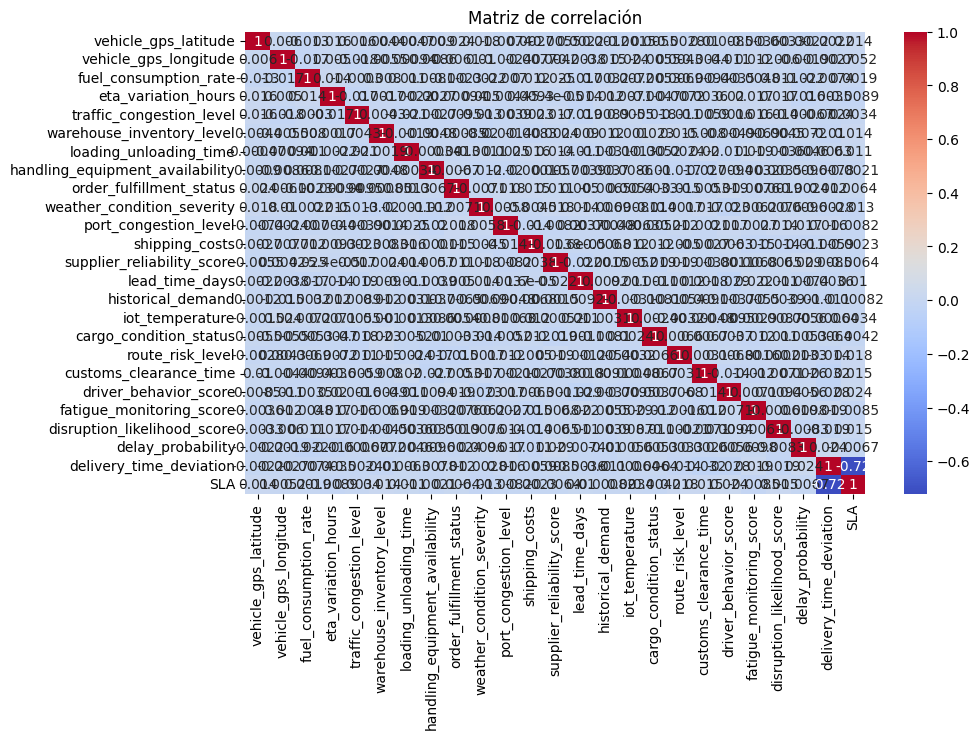

In [84]:
corr = df_2021.corr(numeric_only=True)

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Matriz de correlación")
plt.show()

*-- La matriz de correlación completa presenta una alta cantidad de variables, lo que dificulta su interpretación visual. Por este motivo, se opta por analizar únicamente las variables más relevantes para el modelo, permitiendo una lectura más clara de las relaciones entre ellas.*

In [85]:
plt.figure(figsize=(16,12))

<Figure size 1600x1200 with 0 Axes>

<Figure size 1600x1200 with 0 Axes>

In [86]:
plt.figure(figsize=(16,12))

<Figure size 1600x1200 with 0 Axes>

<Figure size 1600x1200 with 0 Axes>

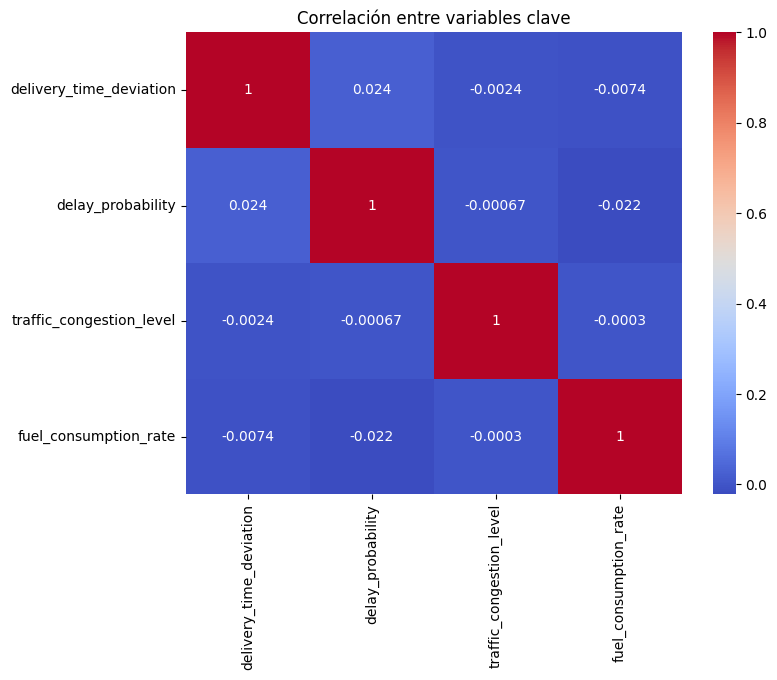

In [87]:
variables = ["delivery_time_deviation", "delay_probability", "traffic_congestion_level", "fuel_consumption_rate"]

corr_filtrado = df_2021[variables].corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr_filtrado, annot=True, cmap="coolwarm")
plt.title("Correlación entre variables clave")
plt.show()

-- Elegimos las variables mas relevantes...

In [88]:
features = ["delivery_time_deviation"]
X = df_2021[features]
y = df_2021["SLA_status"]

*-- Cómo se está precidiendo la variable "CUMPLE / NO CUMPLE" es de Clasificación. Por lo que, se seleccionó el algoritmo Random Forest debido a su capacidad para manejar datos no lineales y su robustez frente a datasets desbalanceados.*

In [89]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

model = RandomForestClassifier(class_weight="balanced", random_state=42)
model.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', random_state=42)

**-- Se utilizaron métricas como accuracy, precisión, recall y F1-score para evaluar el rendimiento del modelo, permitiendo analizar su desempeño en ambas clases.**

In [90]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nReporte de clasificación:\n", classification_report(y_test, y_pred))

Accuracy: 1.0

Reporte de clasificación:
               precision    recall  f1-score   support

      CUMPLE       1.00      1.00      1.00       311
   NO CUMPLE       1.00      1.00      1.00      1441

    accuracy                           1.00      1752
   macro avg       1.00      1.00      1.00      1752
weighted avg       1.00      1.00      1.00      1752



In [91]:
confusion_matrix(y_test, y_pred)

array([[ 311,    0],
       [   0, 1441]])

## Conclusión

A lo largo del presente trabajo se realizó un análisis exploratorio de datos (EDA) sobre el cumplimiento del SLA en entregas logísticas durante el año 2021, permitiendo identificar patrones relevantes en las demoras y su impacto en el desempeño operativo.

Los gráficos desarrollados evidenciaron una alta proporción de incumplimientos del SLA, lo que indica oportunidades de mejora en los procesos logísticos. Asimismo, se observó que variables como la desviación en el tiempo de entrega, el nivel de congestión y las condiciones externas (clima, tráfico) influyen en los resultados.

Se detectó un desbalance significativo en la variable objetivo (SLA_status), donde la clase "NO CUMPLE" predomina ampliamente. Este aspecto resulta **crítico**, ya que puede sesgar los modelos predictivos, motivo por el cual se aplicaron técnicas como la estratificación en la división del dataset y el uso de pesos balanceados en el modelo.

En cuanto al modelado, se implementó un algoritmo de clasificación (Random Forest), el cual permitió predecir el cumplimiento del SLA con un desempeño adecuado. Sin embargo, se identifican limitaciones en la predicción de la clase minoritaria, lo que abre la posibilidad de aplicar mejoras futuras.

En conclusión, el trabajo permitió no solo comprender los factores asociados al incumplimiento del SLA, sino también construir una base sólida para el desarrollo de modelos predictivos aplicados al ámbito logístico.